# Phase 2 — Ablation : normalisation par régime vs normalisation globale (test H3)

Objectif : entraîner le même LSTM (même architecture, même graine, même split) sur FD002,
une fois en ignorant les régimes (comme si on traitait FD002 exactement comme FD001), une
fois en en tenant compte (`10_fd002_pipeline_check.ipynb`).

**Les deux variantes diffèrent sur deux points, pas un seul** : la sélection de capteurs ET la
normalisation. Ce n'est pas un oubli — les deux sont liés par construction : `select_features`
(écart-type global) est justement l'outil qu'on utiliserait si on ignorait les régimes, et il
garde à tort des capteurs constants par régime (cf. note dans `10_fd002_pipeline_check.ipynb`).
La variante "globale" ci-dessous représente donc fidèlement ce que donnerait un pipeline qui
n'aurait pas pris les régimes en compte du tout — pas une version artificiellement dégradée.

Critère « fait » (plan d'exécution, Phase 2) : écart mesuré et rapporté (test H3).

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    assign_regimes,
    compute_norm_stats,
    compute_norm_stats_by_regime,
    fit_regime_clusters,
    make_windows,
    normalize,
    normalize_by_regime,
    select_features,
    select_features_by_regime,
    split_by_unit,
)
from src.torch_model import RULRegressor, set_seed, train_model

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD002.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)

In [2]:
# Variante A ("naïve") : sélection ET normalisation globales, comme si on ignorait les régimes.
selected_sensors_global = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
global_stats = compute_norm_stats(train_raw, selected_sensors_global)
train_global = normalize(train_raw, selected_sensors_global, global_stats)
val_global = normalize(val_raw, selected_sensors_global, global_stats)

train_global_rul = add_piecewise_rul(train_global, cap=RUL_CAP)
val_global_rul = add_piecewise_rul(val_global, cap=RUL_CAP)

X_train_a, y_train_a, _ = make_windows(train_global_rul, selected_sensors_global, window_size=WINDOW_SIZE, target_col="RUL")
X_val_a, y_val_a, _ = make_windows(val_global_rul, selected_sensors_global, window_size=WINDOW_SIZE, target_col="RUL")

print(f"Variante A — capteurs gardés ({len(selected_sensors_global)}) :", selected_sensors_global)
X_train_a.shape, X_val_a.shape

Variante A — capteurs gardés (20) : ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


((37051, 30, 20), (9168, 30, 20))

In [3]:
# Variante B ("régime-aware") : régimes détectés, sélection ET normalisation par régime.
regime_model = fit_regime_clusters(train_raw, SETTING_NAMES, n_regimes=6, seed=SEED)
train_regimes = assign_regimes(train_raw, SETTING_NAMES, regime_model)
val_regimes = assign_regimes(val_raw, SETTING_NAMES, regime_model)

selected_sensors_regime = select_features_by_regime(train_raw, SENSOR_NAMES, train_regimes, std_threshold=1e-2)
regime_stats = compute_norm_stats_by_regime(train_raw, selected_sensors_regime, train_regimes)
train_by_regime = normalize_by_regime(train_raw, selected_sensors_regime, train_regimes, regime_stats)
val_by_regime = normalize_by_regime(val_raw, selected_sensors_regime, val_regimes, regime_stats)

train_regime_rul = add_piecewise_rul(train_by_regime, cap=RUL_CAP)
val_regime_rul = add_piecewise_rul(val_by_regime, cap=RUL_CAP)

X_train_b, y_train_b, _ = make_windows(train_regime_rul, selected_sensors_regime, window_size=WINDOW_SIZE, target_col="RUL")
X_val_b, y_val_b, _ = make_windows(val_regime_rul, selected_sensors_regime, window_size=WINDOW_SIZE, target_col="RUL")

print(f"Variante B — capteurs gardés ({len(selected_sensors_regime)}) :", selected_sensors_regime)
X_train_b.shape, X_val_b.shape

Variante B — capteurs gardés (14) : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


((37051, 30, 14), (9168, 30, 14))

In [4]:
def train_and_evaluate(n_features, X_train, y_train, X_val, y_val):
    set_seed(SEED)  # avant la construction du modèle : l'initialisation des poids en dépend
    model = RULRegressor(n_features=n_features, hidden_size=64)
    model, _ = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=SEED)

    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

    return model, rmse(y_val, y_pred), asymmetric_score(y_val, y_pred)


model_a, rmse_a, score_a = train_and_evaluate(len(selected_sensors_global), X_train_a, y_train_a, X_val_a, y_val_a)
model_b, rmse_b, score_b = train_and_evaluate(len(selected_sensors_regime), X_train_b, y_train_b, X_val_b, y_val_b)

ablation_results = pd.DataFrame([
    {"normalisation": "Globale (sans régime)", "n_capteurs": len(selected_sensors_global), "RMSE": rmse_a, "score_asymétrique": score_a},
    {"normalisation": "Par régime", "n_capteurs": len(selected_sensors_regime), "RMSE": rmse_b, "score_asymétrique": score_b},
])
ablation_results

,normalisation,n_capteurs,RMSE,score_asymétrique
0,Globale (sans régime),20,18.178780,81053.938110
1,Par régime,14,15.074154,42105.297588


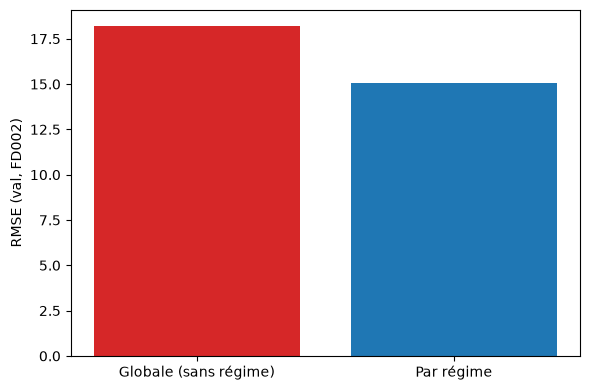

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ablation_results["normalisation"], ablation_results["RMSE"], color=["tab:red", "tab:blue"])
ax.set_ylabel("RMSE (val, FD002)")
fig.tight_layout()

**Ce que montre cette figure** : les deux barres viennent du même modèle, même graine, même
capteurs, même split — seule la normalisation diffère. Si la barre "par régime" est nettement
plus basse, ça confirme l'hypothèse (test H3) : ignorer les régimes opérationnels handicape
le modèle, parce qu'il doit alors apprendre à distinguer "changement de régime" de "vraie
dégradation" à partir des mêmes capteurs bruts, sans qu'on l'y ait aidé. Si l'écart est faible,
ça voudrait dire que le LSTM absorbe déjà cette variation par lui-même (plausible, puisqu'il
voit aussi les 3 réglages opérationnels si on les avait inclus — ici on ne normalise que les
capteurs, les réglages ne sont pas des features du modèle).

In [6]:
# Sauvegarde du modèle B (normalisation par régime, celui qu'on garde) : réutilisé tel quel
# par app.py pour la démo interactive FD002, sans ré-entraînement.
import os

os.makedirs("../models", exist_ok=True)
torch.save(model_b.state_dict(), "../models/lstm_fd002_seed42.pt")